In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
np.random.seed(0) # for reproducibility

## Упражнения

### Упражнение № 1
Это упражнение относится к [Примеру 1](#example-1-static-one-dimensional-data).
1. Выберите значение для оценочной дисперсии модели `Q_est`, которое больше оценочной дисперсии измерения `R_est`.
2. Повторите анализ Примера 1 для этого нового значения.
3. Сходится ли оценка KF?
4. Почему изменились оценки? Они выглядят более шумными, чем раньше? Почему?

### Упражнение №2

Это упражнение относится к [Примеру 2](#example-2-dynamic-one-dimensional-data).

В случае, который мы рассмотрели выше, оценка KF была близка к измерениям, и оба отличались от истинного значения.
Изменяйте параметры алгоритма, пока не найдете некоторые комбинации, которые достигают следующего:

1. Измерения, оценка KF и истинное значение все близки.
2. Измерения, оценка KF и истинное значение все заметно отличаются.
3. Измерения близки к истинному значению, но оценка KF отличается.

Обсудите свои выводы.

### Упражнение №3

Это упражнение относится к [Примеру 3](#example-3-dynamic-two-dimensional-data).

В исходном примере мы использовали и Положение, и Скорость (модель PV) в векторе состояния, т. е. $\boldsymbol{x} = \begin{bmatrix} x & y & \dot x & \dot y \end{bmatrix}^T$.

Что произойдет, если мы используем только Положение (модель P) для описания состояния? В конце концов, наши измерения предоставляют только положение. Действительно ли нам нужно включать скорость?

1. Перепишите алгоритм выше для модели P.

**💡 Подсказка:** каков размер вектора состояния в этом случае? Каковы размерности матриц, характеризующих систему?

**Упражнения:**

**Упражнение 1**

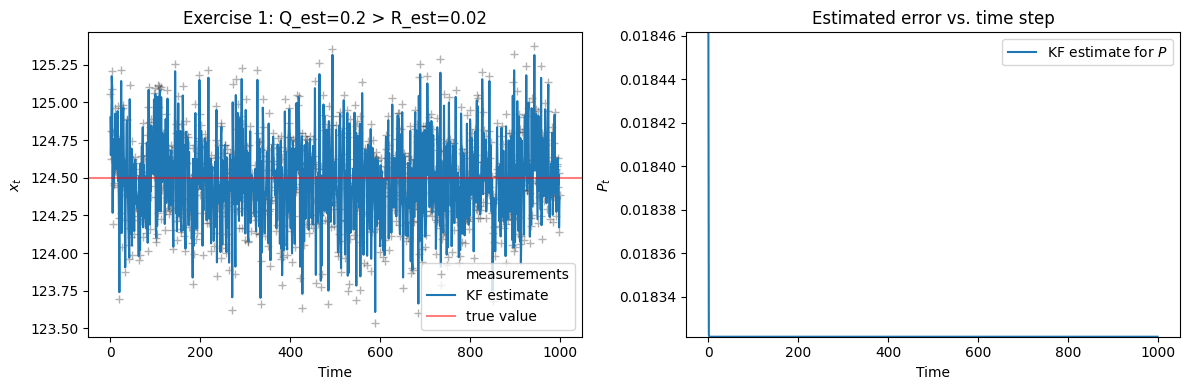

Exercise 1: converges to true value? True


In [10]:
# Estimated covariances
Q_est = 1e-4
R_est = 2e-2

def plot_1d_comparison(measurements_made, estimate, true_value, axis):
    axis.plot(measurements_made,'k+',label='measurements',alpha=0.3)
    axis.plot(estimate,'-',label='KF estimate')
    if not isinstance(true_value, (list, tuple, np.ndarray)):
        # plot line for a constant value
        axis.axhline(true_value,color='r',label='true value', alpha=0.5)
    else:
        # for a list, tuple or array, plot the points
        axis.plot(true_value,color='r',label='true value', alpha=0.5)
    axis.legend(loc = 'lower right')
    axis.set_title('Estimated position vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$x_t$')

def plot_1d_error(estimated_error, lower_limit, upper_limit, axis):
    # lower_limit and upper_limit are the lower and upper limits of the vertical axis
    axis.plot(estimated_error, label='KF estimate for $P$')
    axis.legend(loc = 'upper right')
    axis.set_title('Estimated error vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$P_t$')
    plt.setp(axis,'ylim',[lower_limit, upper_limit])

def kalman_1d(x, P, measurement, R_est, Q_est):

    # Prediction
    x_pred = x
    P_pred = P + Q_est

    # Update
    K = P_pred / (P_pred + R_est)
    x_est = x_pred + K * (measurement - x_pred)
    P_est = (1 - K) * P_pred

    return x_est, P_est

mu = 124.5 # Actual position
R = 0.1    # Actual standard deviation of actual measurements (R)
# Generate measurements
n_measurements = 1000 # Change the number of points to see how the convergence changes
Z = np.random.normal(mu, np.sqrt(R), size=n_measurements)

# Q_est > R_est для статического 1D
Q_est_new = 0.2
R_est_new = R_est  # оставим оценку шума измерений прежней

x = 123
P = 0.04
KF_estimate_new = []
KF_error_new = []
for z in Z:
    x, P = kalman_1d(x, P, z, R_est_new, Q_est_new)
    KF_estimate_new.append(x)
    KF_error_new.append(P)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_1d_comparison(Z, KF_estimate_new, mu, axes[0])
plot_1d_error(KF_error_new, min(KF_error_new), max(KF_error_new), axes[1])
axes[0].set_title(f"Exercise 1: Q_est={Q_est_new} > R_est={R_est_new}")
plt.tight_layout(); plt.show()

print("Exercise 1: converges to true value?", abs(np.mean(KF_estimate_new[-200:]) - mu) < 0.5)

При увеличении Q_est фильтр начинает больше доверять модели (и допускает большие изменения состояния), поэтому оценка может стать «более подвижной» и шумной.

**Упражнение 2**

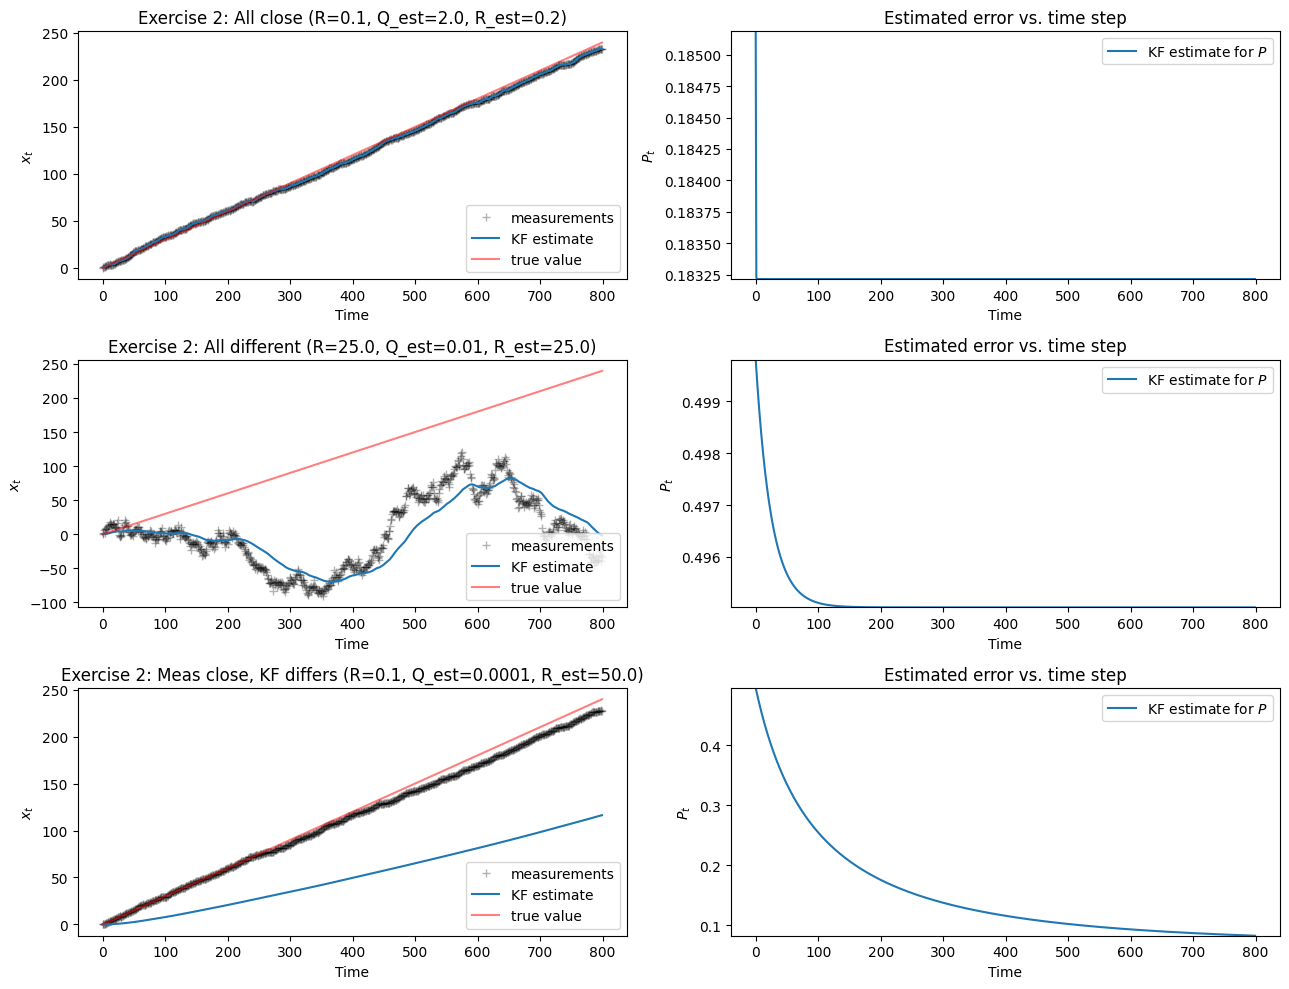

In [11]:
# Динамические 1D данные (подбор параметров)
def _gen_dynamic_1d(v0=0.3, x0=0.0, R=4.0, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    Zv = rng.normal(v0, np.sqrt(R), size=n)
    Zx = np.zeros(n)
    for t in range(n - 1):
        Zx[t + 1] = Zx[t] + Zv[t]
    Xt = x0 + v0 * np.arange(n)
    return Zx, Xt

def _run_kf_dynamic(Zx, Xt, x_init=0.0, P_init=0.5, Q_est=4.0, R_est=4.0):
    x = float(x_init)
    P = float(P_init)
    est = []
    err = []
    for z in Zx:
        x, P = kalman_1d(x, P, z, R_est, Q_est)
        est.append(x)
        err.append(P)
    return np.asarray(est), np.asarray(err)

configs = [
    # 1) measurements, KF and true all close
    {"name": "All close", "R": 0.1, "Q_est": 2.0, "R_est": 0.2},
    # 2) all noticeably different
    {"name": "All different", "R": 25.0, "Q_est": 0.01, "R_est": 25.0},
    # 3) measurements close to true, KF differs
    {"name": "Meas close, KF differs", "R": 0.1, "Q_est": 1e-4, "R_est": 50.0},
]

fig, axes = plt.subplots(len(configs), 2, figsize=(13, 10))
for row, cfg in enumerate(configs):
    Zx_cfg, Xt_cfg = _gen_dynamic_1d(R=cfg["R"], n=800, seed=row)
    est, err = _run_kf_dynamic(Zx_cfg, Xt_cfg, x_init=0.0, P_init=0.5, Q_est=cfg["Q_est"], R_est=cfg["R_est"])
    plot_1d_comparison(Zx_cfg, est, Xt_cfg, axes[row, 0])
    plot_1d_error(err, float(np.min(err)), float(np.max(err)), axes[row, 1])
    axes[row, 0].set_title(f"Exercise 2: {cfg['name']} (R={cfg['R']}, Q_est={cfg['Q_est']}, R_est={cfg['R_est']})")
plt.tight_layout(); plt.show()

Разные сочетания (R, Q_est, R_est) показывают компромисс: либо следовать измерениям, либо сглаживать, либо «залипать» на предсказании.

**Упражнение 3**

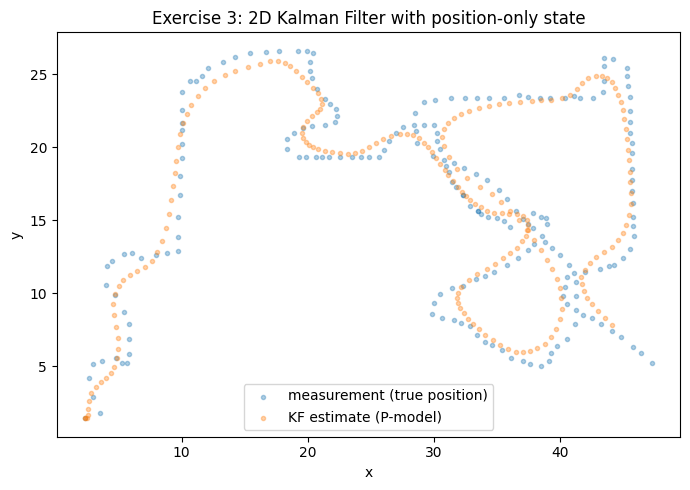

In [22]:
# Загрузим некоторые предварительно вычисленные данные
xy_motion = pd.read_csv('https://zenodo.org/records/10951538/files/kf_ts1.csv?download=1',
                        header = None).values.astype('float32')

# 2D Kalman Filter только с положением (P-model)
# Вектор состояния: x = [x, y]^T (размер 2)
# Матрицы: A (2x2), H (2x2), Q (2x2), R (2x2)
kalman_p = cv2.KalmanFilter(2, 2, 0) # 2 states, 2 measurements, 0 control vector
kalman_p.transitionMatrix = np.array([[1, 0], [0, 1]], np.float32)  # A
kalman_p.measurementMatrix = np.array([[1, 0], [0, 1]], np.float32)  # H

q = 1.0
r = 20.0
kalman_p.processNoiseCov = (q * np.eye(2)).astype(np.float32)
kalman_p.measurementNoiseCov = (r * np.eye(2)).astype(np.float32)
kalman_p.errorCovPost = (1.0 * np.eye(2)).astype(np.float32)

kalman_p.statePost = np.array([[xy_motion[0, 0]], [xy_motion[0, 1]]], np.float32)

KF_est_p = [] # To store the position estimate at each time point

for meas in xy_motion:
    meas_column = meas.reshape(2, 1).astype(np.float32)
    pred = kalman_p.predict() # predicts new state using the model
    kalman_p.correct(meas_column) # updates estimated state with the measurement
    KF_est_p.append((float(pred[0, 0]), float(pred[1, 0]))) # store the estimated position

x_est_p, y_est_p = zip(*KF_est_p)
x_true, y_true = xy_motion[:, 0], xy_motion[:, 1]
plt.figure(figsize=(7, 5))
plt.scatter(x_true, y_true, marker='.', label='measurement (true position)', alpha=0.35)
plt.scatter(x_est_p, y_est_p, marker='.', label='KF estimate (P-model)', alpha=0.35)
plt.legend(loc='lower center')
plt.title('Exercise 3: 2D Kalman Filter with position-only state')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout(); plt.show()

Модель P (только положение) работает, но обычно хуже сглаживает траекторию, чем PV-модель, потому что скорость как скрытое состояние помогает фильтру предсказывать движение.